# 05 — Diagnostics

Comprehensive model diagnostics for the linear and logistic regression models.

**Linear model diagnostics:**
1. Residual plots (4-panel)
2. Formal tests: Breusch-Pagan, Shapiro-Wilk
3. VIF analysis
4. Cook's distance and DFBETAS
5. Robust regression comparison
6. Sensitivity analysis (exclude SKCM + UCEC)

**Logistic model diagnostics:**
7. Deviance and Pearson residuals
8. Standard vs Firth comparison

In [1]:
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats as sp_stats
from statsmodels.stats.diagnostic import het_breuschpagan

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.plotting import set_style, save_fig, plot_residual_diagnostics, plot_vif_bar
from src.stats import (
    fit_ols_formula, fit_robust_regression, compute_vif,
    extract_model_summary, cooks_distance, fit_firth_logistic,
)
from src.preprocessing import get_model_df

set_style()
FIGURES_DIR = PROJECT_ROOT / "figures"

df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "tmb_merged.parquet")
print(f"Loaded {df.shape[0]} samples")

Loaded 10953 samples


## 0. Refit Final Linear Model

In [2]:
predictors = ["age_at_diagnosis", "cancer_type", "sex", "msi_status",
              "aneuploidy_score", "fraction_genome_altered", "wgd_status"]
available = [c for c in predictors if c in df.columns]
model_df = get_model_df(df, available, "log_tmb")

# Exclude hypermutators for cleaner diagnostics
model_df["hypermutator"] = (np.expm1(model_df["log_tmb"]) > 50).astype(int)
n_hyper = model_df["hypermutator"].sum()
model_df = model_df[model_df["hypermutator"] == 0].copy()
print(f"Complete cases: {len(model_df)} (excluded {n_hyper} hypermutators)")

full_formula = "log_tmb ~ age_at_diagnosis + C(cancer_type) + C(sex) + C(msi_status) + aneuploidy_score + fraction_genome_altered + C(wgd_status)"
m_full = fit_ols_formula(model_df, full_formula)
print(f"Full model adj R²: {m_full.rsquared_adj:.4f}")

Complete cases: 9390 (excluded 178 hypermutators)
Full model adj R²: 0.6237


## 1. Four-Panel Residual Diagnostics

In [3]:
import importlib
import src.plotting as plotting

importlib.reload(plotting)
plot_residual_diagnostics = plotting.plot_residual_diagnostics

  Saved: diagnostics_residuals_4panel.png, diagnostics_residuals_4panel.pdf


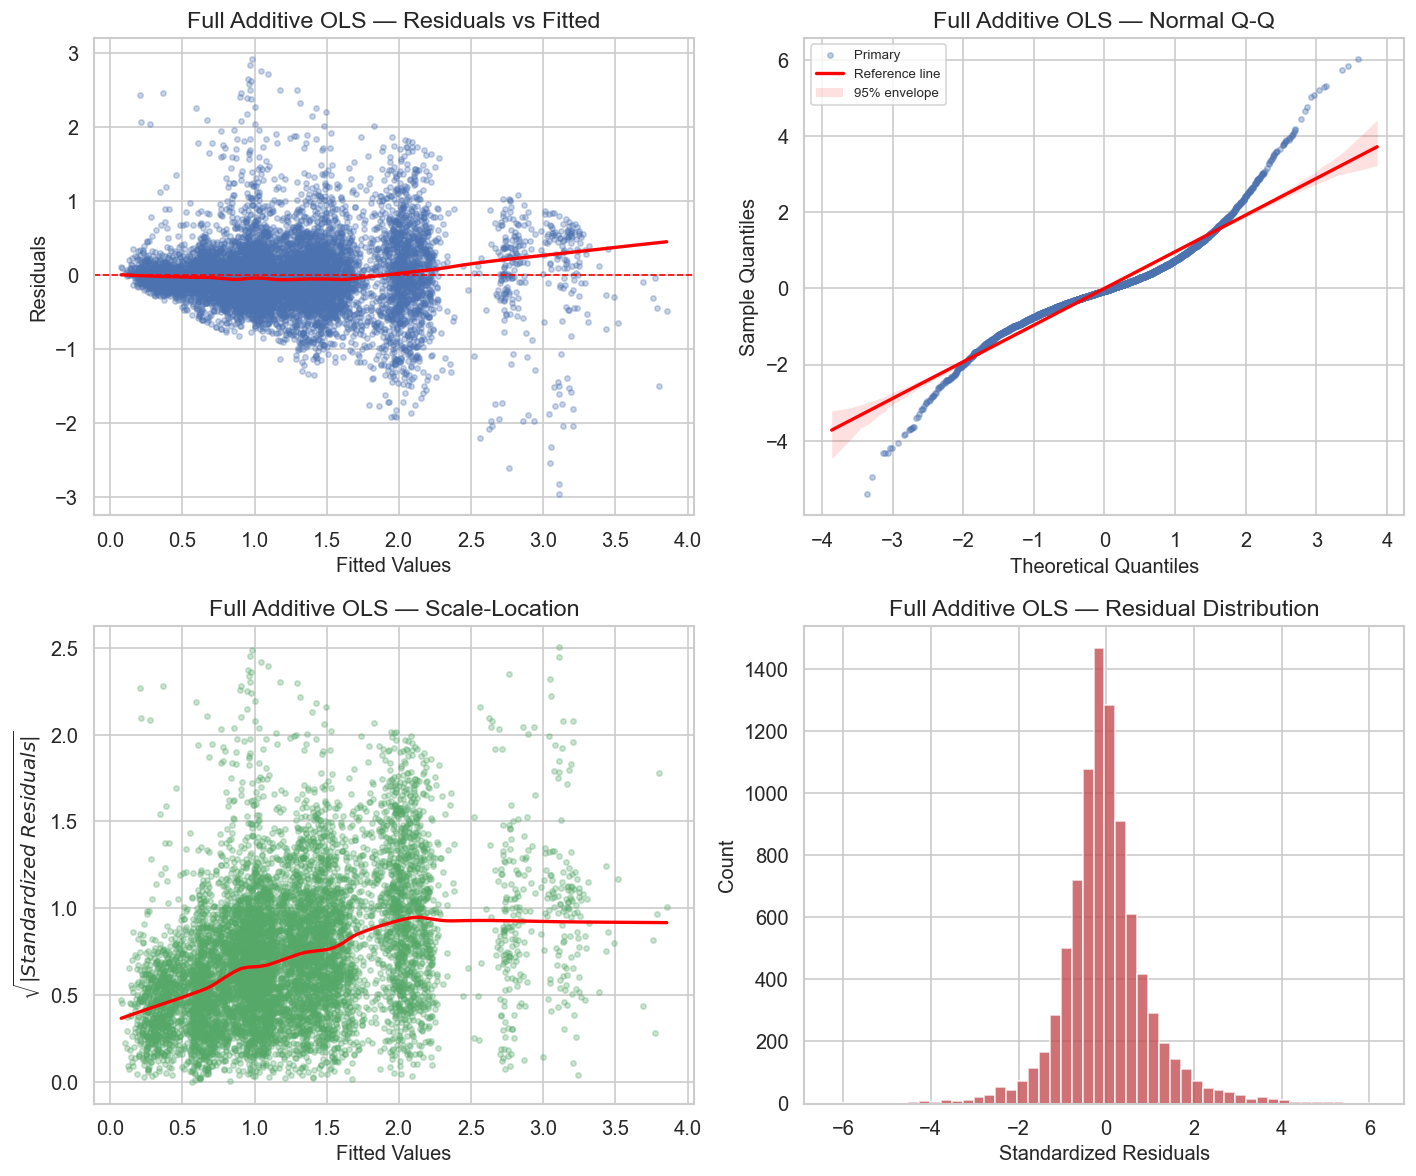

In [4]:
# Use externally studentized residuals for a more informative Q-Q panel.
influence = m_full.get_influence()
qq_resid = influence.resid_studentized_external

fig = plot_residual_diagnostics(
    m_full.fittedvalues.values,
    m_full.resid.values,
    model_name="Full Additive OLS",
    qq_residuals=qq_resid,
    qq_show_ci=True,
    qq_ci_level=0.95,
)
save_fig(fig, "diagnostics_residuals_4panel", FIGURES_DIR)
plt.show()

## 2. Formal Tests

In [5]:
# Breusch-Pagan test for heteroscedasticity
bp_stat, bp_pval, bp_fstat, bp_fpval = het_breuschpagan(m_full.resid, m_full.model.exog)
print("=== Breusch-Pagan Test (Heteroscedasticity) ===")
print(f"  LM statistic: {bp_stat:.3f}")
print(f"  p-value:      {bp_pval:.2e}")
print(f"  F-statistic:  {bp_fstat:.3f}")
print(f"  F p-value:    {bp_fpval:.2e}")
print(f"  Conclusion:   {'Heteroscedasticity detected (p < 0.05)' if bp_pval < 0.05 else 'Homoscedasticity (p >= 0.05)'}")

=== Breusch-Pagan Test (Heteroscedasticity) ===
  LM statistic: 693.710
  p-value:      2.31e-123
  F-statistic:  22.044
  F p-value:    1.27e-129
  Conclusion:   Heteroscedasticity detected (p < 0.05)


In [6]:
# Shapiro-Wilk test for normality of residuals
# Use a random subsample if n > 5000 (Shapiro-Wilk limit)
resids = m_full.resid.values
if len(resids) > 5000:
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(resids), size=5000, replace=False)
    resids_sample = resids[sample_idx]
    print("(Using random subsample of 5000 for Shapiro-Wilk test)")
else:
    resids_sample = resids

sw_stat, sw_pval = sp_stats.shapiro(resids_sample)
print(f"\n=== Shapiro-Wilk Test (Normality) ===")
print(f"  W statistic: {sw_stat:.6f}")
print(f"  p-value:     {sw_pval:.2e}")
print(f"  Conclusion:  {'Non-normal residuals (p < 0.05)' if sw_pval < 0.05 else 'Normal residuals (p >= 0.05)'}")
print(f"\n  Note: With large samples, even small deviations from normality are detected.")
print(f"  Practically, OLS is robust to non-normality when n is large.")

(Using random subsample of 5000 for Shapiro-Wilk test)

=== Shapiro-Wilk Test (Normality) ===
  W statistic: 0.926778
  p-value:     4.13e-44
  Conclusion:  Non-normal residuals (p < 0.05)

  Note: With large samples, even small deviations from normality are detected.
  Practically, OLS is robust to non-normality when n is large.


## 2.5 HC3 Robust Standard Errors

The Breusch-Pagan test confirms heteroscedasticity — residual variance increases with fitted values,
driven by cancer types with inherently variable TMB (e.g., melanoma, endometrial).
OLS coefficient estimates remain unbiased under heteroscedasticity, but classical
standard errors become unreliable. HC3 heteroscedasticity-consistent standard errors
correct the inference without changing the model or dropping data.

In [7]:
m_hc3 = m_full.get_robustcov_results(cov_type="HC3")

hc3_comparison = pd.DataFrame({
    "variable": m_hc3.model.exog_names,
    "coef": m_hc3.params,
    "se_classical": m_full.bse,
    "se_HC3": m_hc3.bse,
    "p_classical": m_full.pvalues,
    "p_HC3": m_hc3.pvalues,
})
hc3_comparison["se_ratio"] = (hc3_comparison["se_HC3"] / hc3_comparison["se_classical"]).round(3)

non_ct = hc3_comparison[~hc3_comparison["variable"].str.startswith("C(cancer_type")]
print("=== Classical vs HC3 Robust Standard Errors ===\n")
print(non_ct[["variable", "coef", "se_classical", "se_HC3", "se_ratio", "p_classical", "p_HC3"]].to_string(
    index=False, float_format=lambda x: f"{x:.4g}"
))

print(f"\nMean SE ratio (HC3 / classical): {non_ct['se_ratio'].mean():.3f}")
print("  Ratio > 1 → classical SEs understate uncertainty (HC3 is more conservative)")
print("  Ratio ≈ 1 → heteroscedasticity has minimal impact on that predictor")

sig_changed = non_ct[(non_ct["p_classical"] < 0.05) != (non_ct["p_HC3"] < 0.05)]
if len(sig_changed) == 0:
    print("\nNo predictor changes significance status between classical and HC3.")
else:
    print(f"\n{len(sig_changed)} predictor(s) changed significance status:")
    print(sig_changed[["variable", "p_classical", "p_HC3"]].to_string(index=False))

=== Classical vs HC3 Robust Standard Errors ===

               variable      coef  se_classical    se_HC3  se_ratio  p_classical      p_HC3
              Intercept     2.055       0.06228   0.06963     1.118   3.178e-225 1.166e-182
         C(sex)[T.MALE]   0.03685       0.01263   0.01306     1.034     0.003533   0.004804
   C(msi_status)[T.MSS]    -1.744       0.02963   0.04933     1.665            0 3.458e-256
     C(wgd_status)[T.1]    0.1302       0.01685   0.01637     0.971    1.253e-14  2.038e-15
       age_at_diagnosis  0.005395     0.0004135 0.0004294     1.038    1.508e-38  6.656e-36
       aneuploidy_score -0.001754      0.001207  0.001244     1.031       0.1462     0.1587
fraction_genome_altered    0.2416       0.03357   0.03692       1.1    6.727e-13  6.396e-11

Mean SE ratio (HC3 / classical): 1.137
  Ratio > 1 → classical SEs understate uncertainty (HC3 is more conservative)
  Ratio ≈ 1 → heteroscedasticity has minimal impact on that predictor

No predictor changes signi

## 3. VIF Analysis

Variance Inflation Factors:
               variable      VIF
       age_at_diagnosis 1.029486
       aneuploidy_score 3.338197
fraction_genome_altered 1.818429
             wgd_status 2.349244
  Saved: diagnostics_vif.png, diagnostics_vif.pdf


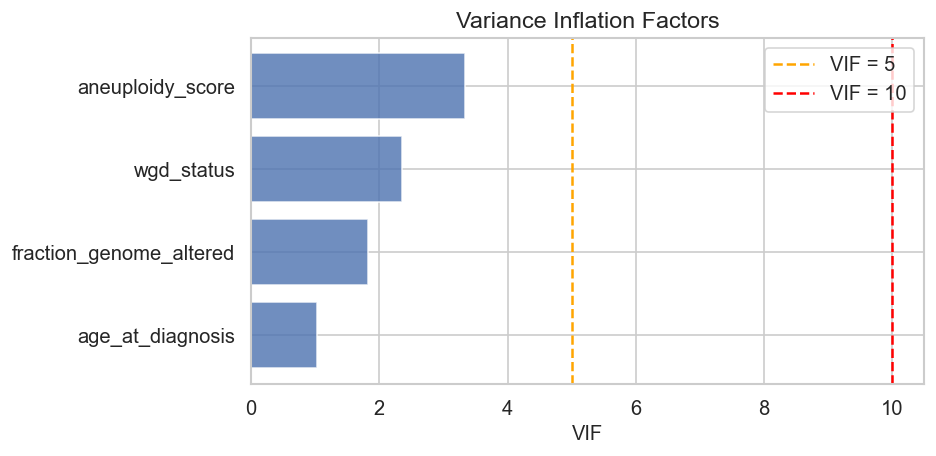


No multicollinearity concern (all VIF < 5).


In [8]:
numeric_predictors = ["age_at_diagnosis", "aneuploidy_score", "fraction_genome_altered", "wgd_status"]
avail_num = [c for c in numeric_predictors if c in model_df.columns]

vif_df = compute_vif(model_df, avail_num)
print("Variance Inflation Factors:")
print(vif_df.to_string(index=False))

fig = plot_vif_bar(vif_df)
save_fig(fig, "diagnostics_vif", FIGURES_DIR)
plt.show()

high_vif = vif_df[vif_df["VIF"] > 5]
if len(high_vif) > 0:
    print(f"\nConcern: {len(high_vif)} variable(s) with VIF > 5 — consider collinearity.")
    print("Aneuploidy score and FGA are biologically correlated (both measure genomic instability).")
else:
    print("\nNo multicollinearity concern (all VIF < 5).")

## 4. Cook's Distance

Cook's distance threshold (4/n): 0.000450
Influential observations: 353 / 8887 (4.0%)
  Saved: diagnostics_cooks_distance.png, diagnostics_cooks_distance.pdf


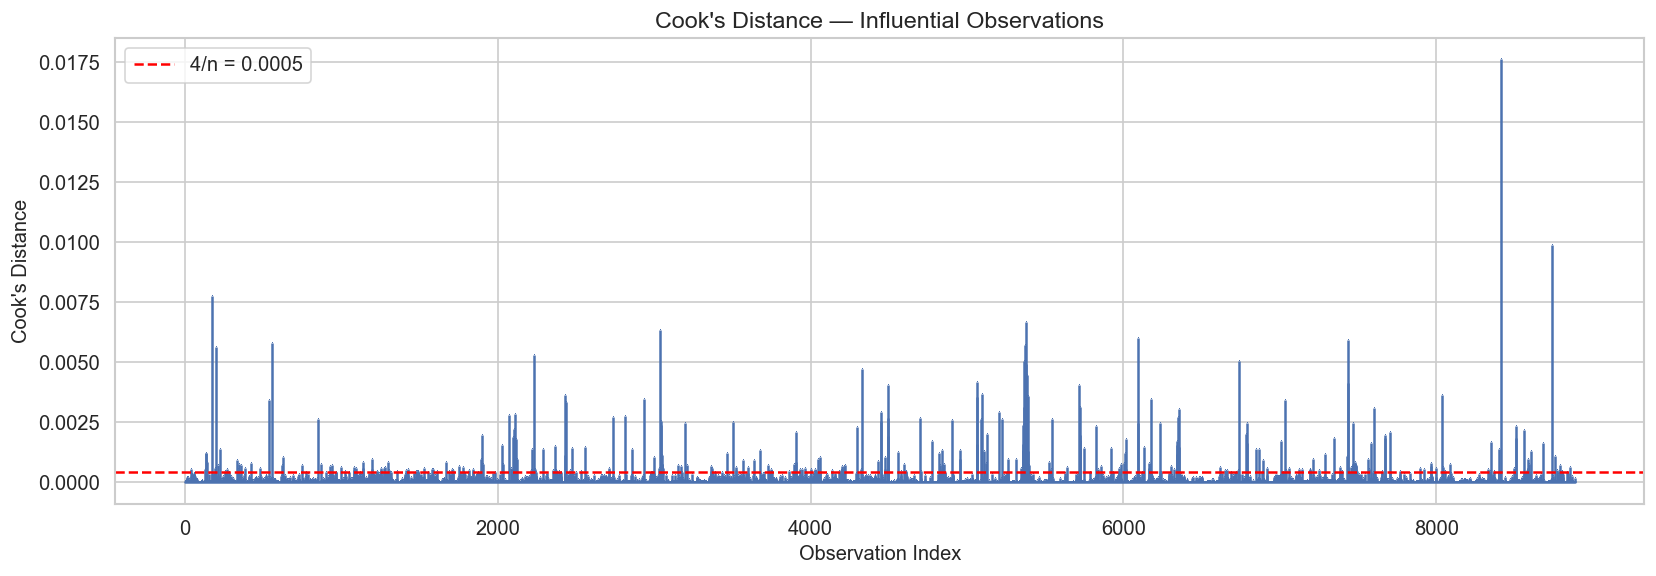

In [9]:
cooks_d = cooks_distance(m_full)
n = int(m_full.nobs)
p = m_full.df_model + 1
threshold = 4 / n

influential = cooks_d[cooks_d > threshold]
print(f"Cook's distance threshold (4/n): {threshold:.6f}")
print(f"Influential observations: {len(influential)} / {n} ({len(influential)/n:.1%})")

# Plot Cook's distance
fig, ax = plt.subplots(figsize=(14, 5))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=",", linefmt="C0-", basefmt="C0-")
ax.axhline(threshold, color="red", ls="--", lw=1.5, label=f"4/n = {threshold:.4f}")
ax.set_xlabel("Observation Index")
ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance — Influential Observations")
ax.legend()
fig.tight_layout()
save_fig(fig, "diagnostics_cooks_distance", FIGURES_DIR)
plt.show()

In [10]:
# Characterize influential observations by cancer type
# Use the model's actual row indices to align Cook's D
if "cancer_type" in model_df.columns:
    model_idx = m_full.model.data.row_labels
    model_subset = model_df.loc[model_idx].copy()
    model_subset["cooks_d"] = cooks_d.values
    model_subset["influential"] = cooks_d.values > threshold
    
    infl_by_ct = (
        model_subset.groupby("cancer_type")["influential"]
        .agg(["sum", "count"])
        .rename(columns={"sum": "n_influential", "count": "n_total"})
    )
    infl_by_ct["pct_influential"] = (infl_by_ct["n_influential"] / infl_by_ct["n_total"] * 100).round(1)
    infl_by_ct = infl_by_ct.sort_values("pct_influential", ascending=False)
    print("Top 10 cancer types by proportion of influential observations:")
    print(infl_by_ct.head(10).to_string())

Top 10 cancer types by proportion of influential observations:
                                     n_influential  n_total  pct_influential
cancer_type                                                                 
Melanoma                                        47       72             65.3
Mature B-Cell Neoplasms                         13       37             35.1
Adrenocortical Carcinoma                        14       88             15.9
Bladder Cancer                                  42      396             10.6
Cervical Cancer                                 23      275              8.4
Cholangiocarcinoma                               3       36              8.3
Miscellaneous Neuroepithelial Tumor              2       27              7.4
Colorectal Cancer                               22      480              4.6
Non-Small Cell Lung Cancer                      41      922              4.4
Sarcoma                                         10      226              4.4


## 5. DFBETAS for Key Coefficients

  Saved: diagnostics_dfbetas_age.png, diagnostics_dfbetas_age.pdf


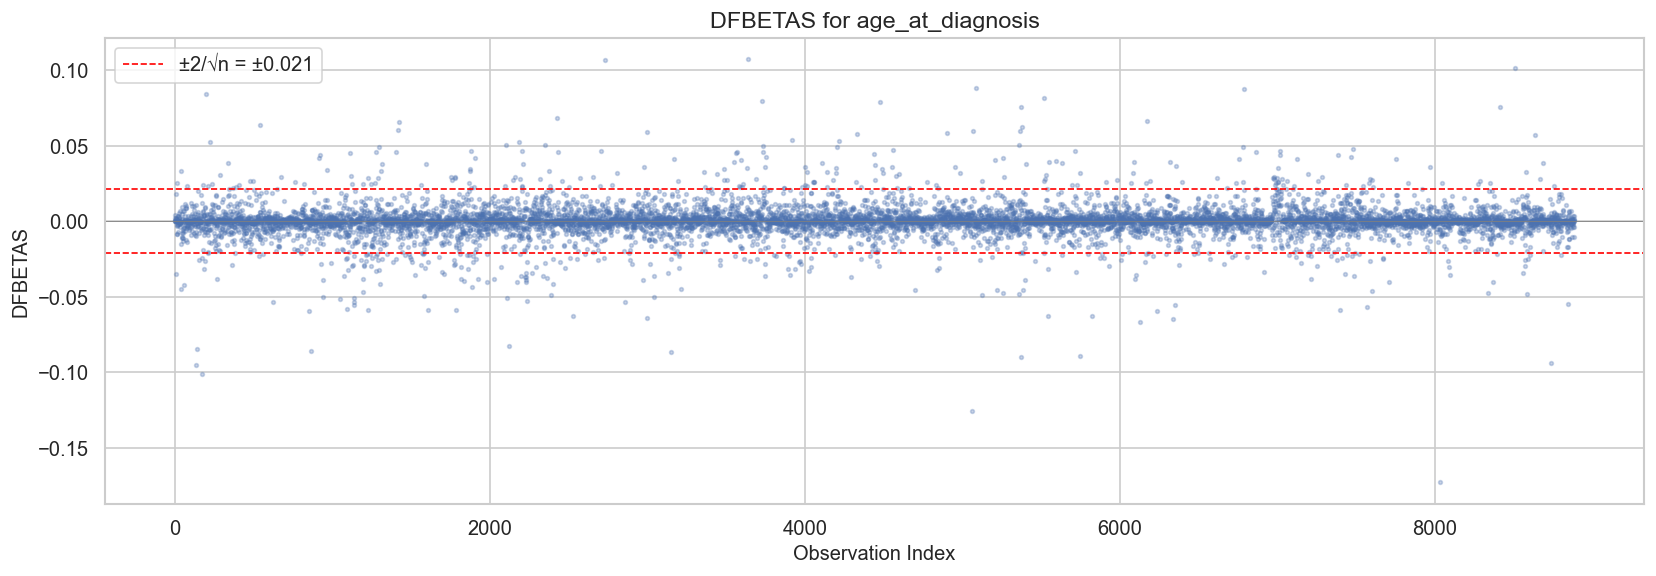

Observations with |DFBETAS| > threshold for age: 482 (5.4%)


In [11]:
influence = m_full.get_influence()
dfbetas = influence.dfbetas
dfbetas_threshold = 2 / np.sqrt(n)

# Focus on age coefficient (typically index 1 after intercept)
param_names = m_full.params.index.tolist()
age_idx = None
for i, name in enumerate(param_names):
    if "age" in name.lower():
        age_idx = i
        break

if age_idx is not None:
    n_dfbetas = dfbetas.shape[0]
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.scatter(range(n_dfbetas), dfbetas[:, age_idx], alpha=0.3, s=5)
    ax.axhline(dfbetas_threshold, color="red", ls="--", lw=1, label=f"±2/√n = ±{dfbetas_threshold:.3f}")
    ax.axhline(-dfbetas_threshold, color="red", ls="--", lw=1)
    ax.axhline(0, color="grey", ls="-", lw=0.5)
    ax.set_xlabel("Observation Index")
    ax.set_ylabel("DFBETAS")
    ax.set_title(f"DFBETAS for {param_names[age_idx]}")
    ax.legend()
    fig.tight_layout()
    save_fig(fig, "diagnostics_dfbetas_age", FIGURES_DIR)
    plt.show()
    
    n_influential_age = np.sum(np.abs(dfbetas[:, age_idx]) > dfbetas_threshold)
    print(f"Observations with |DFBETAS| > threshold for age: {n_influential_age} ({n_influential_age/n:.1%})")

## 6. Robust Regression (Huber M-estimator)

In [12]:
m_robust = fit_robust_regression(model_df, full_formula, m_estimator="huber")

# Compare OLS vs robust coefficients
ols_coef = extract_model_summary(m_full)
robust_coef = extract_model_summary(m_robust)

# Non-cancer-type comparison
ols_non_ct = ols_coef[~ols_coef["variable"].str.startswith("C(cancer_type")]
robust_non_ct = robust_coef[~robust_coef["variable"].str.startswith("C(cancer_type")]

comparison = ols_non_ct[["variable", "coef"]].merge(
    robust_non_ct[["variable", "coef"]],
    on="variable",
    suffixes=("_OLS", "_Robust"),
)
comparison["diff"] = comparison["coef_OLS"] - comparison["coef_Robust"]
# Handle division by zero for near-zero coefficients
comparison["pct_diff"] = np.where(
    comparison["coef_OLS"].abs() > 1e-10,
    ((comparison["diff"] / comparison["coef_OLS"]) * 100).round(1),
    0.0,
)

print("OLS vs Robust (Huber) coefficients:")
print(comparison.to_string(index=False))
print(f"\nLarge differences suggest influential outliers are affecting OLS estimates.")

OLS vs Robust (Huber) coefficients:
               variable  coef_OLS  coef_Robust      diff  pct_diff
              Intercept  2.054780     2.185607 -0.130827      -6.4
         C(sex)[T.MALE]  0.036846     0.020353  0.016493      44.8
   C(msi_status)[T.MSS] -1.743721    -1.968427  0.224706     -12.9
     C(wgd_status)[T.1]  0.130183     0.131004 -0.000821      -0.6
       age_at_diagnosis  0.005395     0.005946 -0.000551     -10.2
       aneuploidy_score -0.001754    -0.002354  0.000600     -34.2
fraction_genome_altered  0.241555     0.248738 -0.007183      -3.0

Large differences suggest influential outliers are affecting OLS estimates.


## 6.5 Residual-Improved OLS (Nonlinear Terms + Robust Inference)

To better match residual assumptions, fit a more flexible specification that allows nonlinear effects in continuous predictors and an MSI-dependent aneuploidy pattern. Then compare diagnostics to the baseline additive OLS model.

  Saved: diagnostics_residuals_4panel_enhanced.png, diagnostics_residuals_4panel_enhanced.pdf


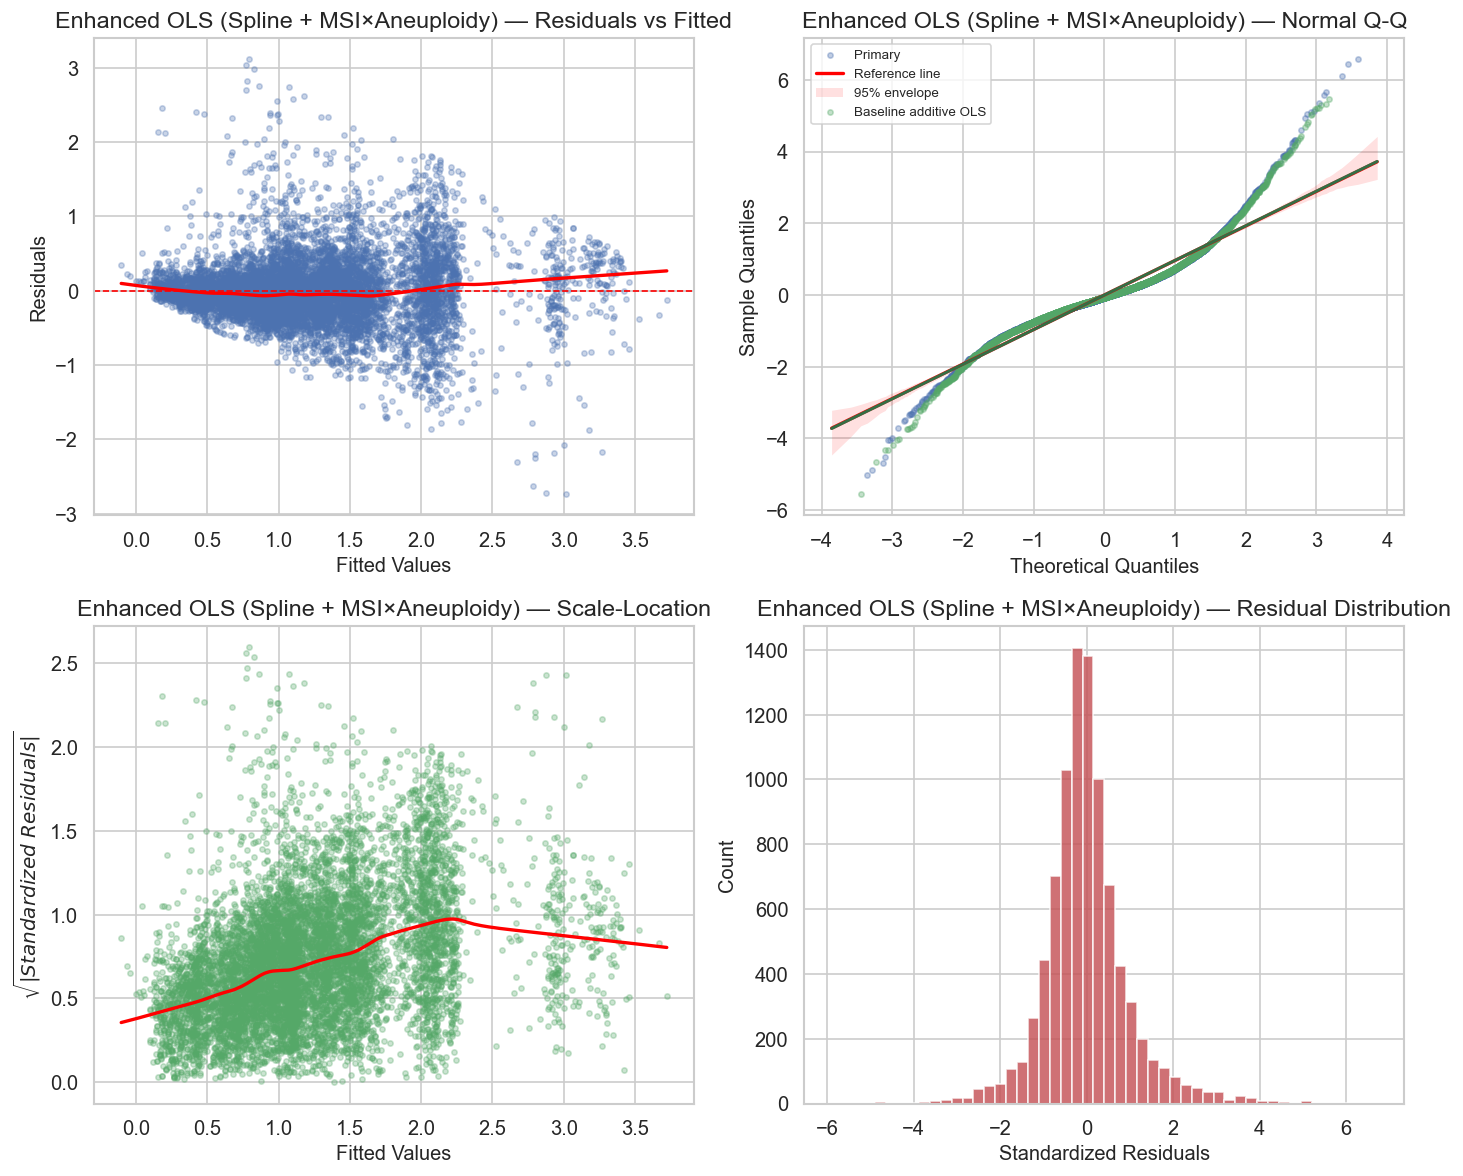

=== Baseline vs Enhanced Residual Diagnostics ===
Adj R²: baseline=0.6237, enhanced=0.6382
Skewness: baseline=0.572, enhanced=0.775 (closer to 0 is better)
Kurtosis: baseline=7.617, enhanced=7.988 (closer to 3 is better)
Breusch-Pagan p: baseline=2.31e-123, enhanced=2.52e-126
Shapiro-Wilk p: baseline=4.13e-44, enhanced=3.23e-45

Enhanced model (HC3 robust SE) — selected terms:
                                          variable      coef   se_hc3         p_hc3
                                         Intercept  2.468883 0.091529 4.582835e-154
                              C(msi_status)[T.MSS] -2.129178 0.061354 1.674625e-247
                     bs(age_at_diagnosis, df=4)[0] -0.042176 0.093753  6.528221e-01
                     bs(age_at_diagnosis, df=4)[1]  0.363713 0.054468  2.576418e-11
                     bs(age_at_diagnosis, df=4)[2]  0.274754 0.074419  2.238469e-04
                     bs(age_at_diagnosis, df=4)[3]  0.375539 0.069098  5.630063e-08
                     bs(aneuploi

In [13]:
# Flexible model: splines for continuous predictors + MSI-by-aneuploidy interaction
enhanced_formula = (
    "log_tmb ~ bs(age_at_diagnosis, df=4) + C(cancer_type) + C(sex) + C(msi_status) "
    "+ bs(aneuploidy_score, df=4) + bs(fraction_genome_altered, df=4) "
    "+ C(msi_status):bs(aneuploidy_score, df=4) + C(wgd_status)"
)

m_enh = fit_ols_formula(model_df, enhanced_formula)
influence_enh = m_enh.get_influence()
qq_resid_enh = influence_enh.resid_studentized_external

fig = plot_residual_diagnostics(
    m_enh.fittedvalues.values,
    m_enh.resid.values,
    model_name="Enhanced OLS (Spline + MSI×Aneuploidy)",
    qq_residuals=qq_resid_enh,
    qq_compare_residuals=qq_resid,
    qq_compare_label="Baseline additive OLS",
    qq_show_ci=True,
    qq_ci_level=0.95,
)
save_fig(fig, "diagnostics_residuals_4panel_enhanced", FIGURES_DIR)
plt.show()

# Side-by-side residual metrics
resid_base = m_full.resid.values
resid_enh = m_enh.resid.values

base_skew = sp_stats.skew(resid_base)
enh_skew = sp_stats.skew(resid_enh)
base_kurt = sp_stats.kurtosis(resid_base, fisher=False)
enh_kurt = sp_stats.kurtosis(resid_enh, fisher=False)

bp_stat_enh, bp_pval_enh, bp_fstat_enh, bp_fpval_enh = het_breuschpagan(
    m_enh.resid, m_enh.model.exog
)

# Shapiro (subsample if needed)
resids_enh = m_enh.resid.values
if len(resids_enh) > 5000:
    rng = np.random.default_rng(42)
    sample_idx_enh = rng.choice(len(resids_enh), size=5000, replace=False)
    resids_enh_sample = resids_enh[sample_idx_enh]
else:
    resids_enh_sample = resids_enh

sw_stat_enh, sw_pval_enh = sp_stats.shapiro(resids_enh_sample)

print("=== Baseline vs Enhanced Residual Diagnostics ===")
print(f"Adj R²: baseline={m_full.rsquared_adj:.4f}, enhanced={m_enh.rsquared_adj:.4f}")
print(f"Skewness: baseline={base_skew:.3f}, enhanced={enh_skew:.3f} (closer to 0 is better)")
print(f"Kurtosis: baseline={base_kurt:.3f}, enhanced={enh_kurt:.3f} (closer to 3 is better)")
print(f"Breusch-Pagan p: baseline={bp_pval:.2e}, enhanced={bp_pval_enh:.2e}")
print(f"Shapiro-Wilk p: baseline={sw_pval:.2e}, enhanced={sw_pval_enh:.2e}")

# Robust SE for enhanced model (HC3)
m_enh_hc3 = m_enh.get_robustcov_results(cov_type="HC3")
coef_hc3 = pd.DataFrame({
    "variable": m_enh_hc3.model.exog_names,
    "coef": m_enh_hc3.params,
    "se_hc3": m_enh_hc3.bse,
    "p_hc3": m_enh_hc3.pvalues,
})

print("\nEnhanced model (HC3 robust SE) — selected terms:")
sel = coef_hc3[
    coef_hc3["variable"].str.contains(
        "Intercept|msi_status|bs\\(age_at_diagnosis|bs\\(aneuploidy_score|bs\\(fraction_genome_altered|wgd_status",
        regex=True,
    )
]
print(sel.head(20).to_string(index=False))

## 6.6 WLS + Quantile Regression Robustness Checks

To directly address heteroscedasticity and heavy tails, fit:
1) weighted least squares (WLS) using a variance model from enhanced-OLS residuals, and
2) median quantile regression (q=0.5), which is less sensitive to tail outliers than mean-based OLS.

  Saved: diagnostics_residuals_4panel_wls.png, diagnostics_residuals_4panel_wls.pdf


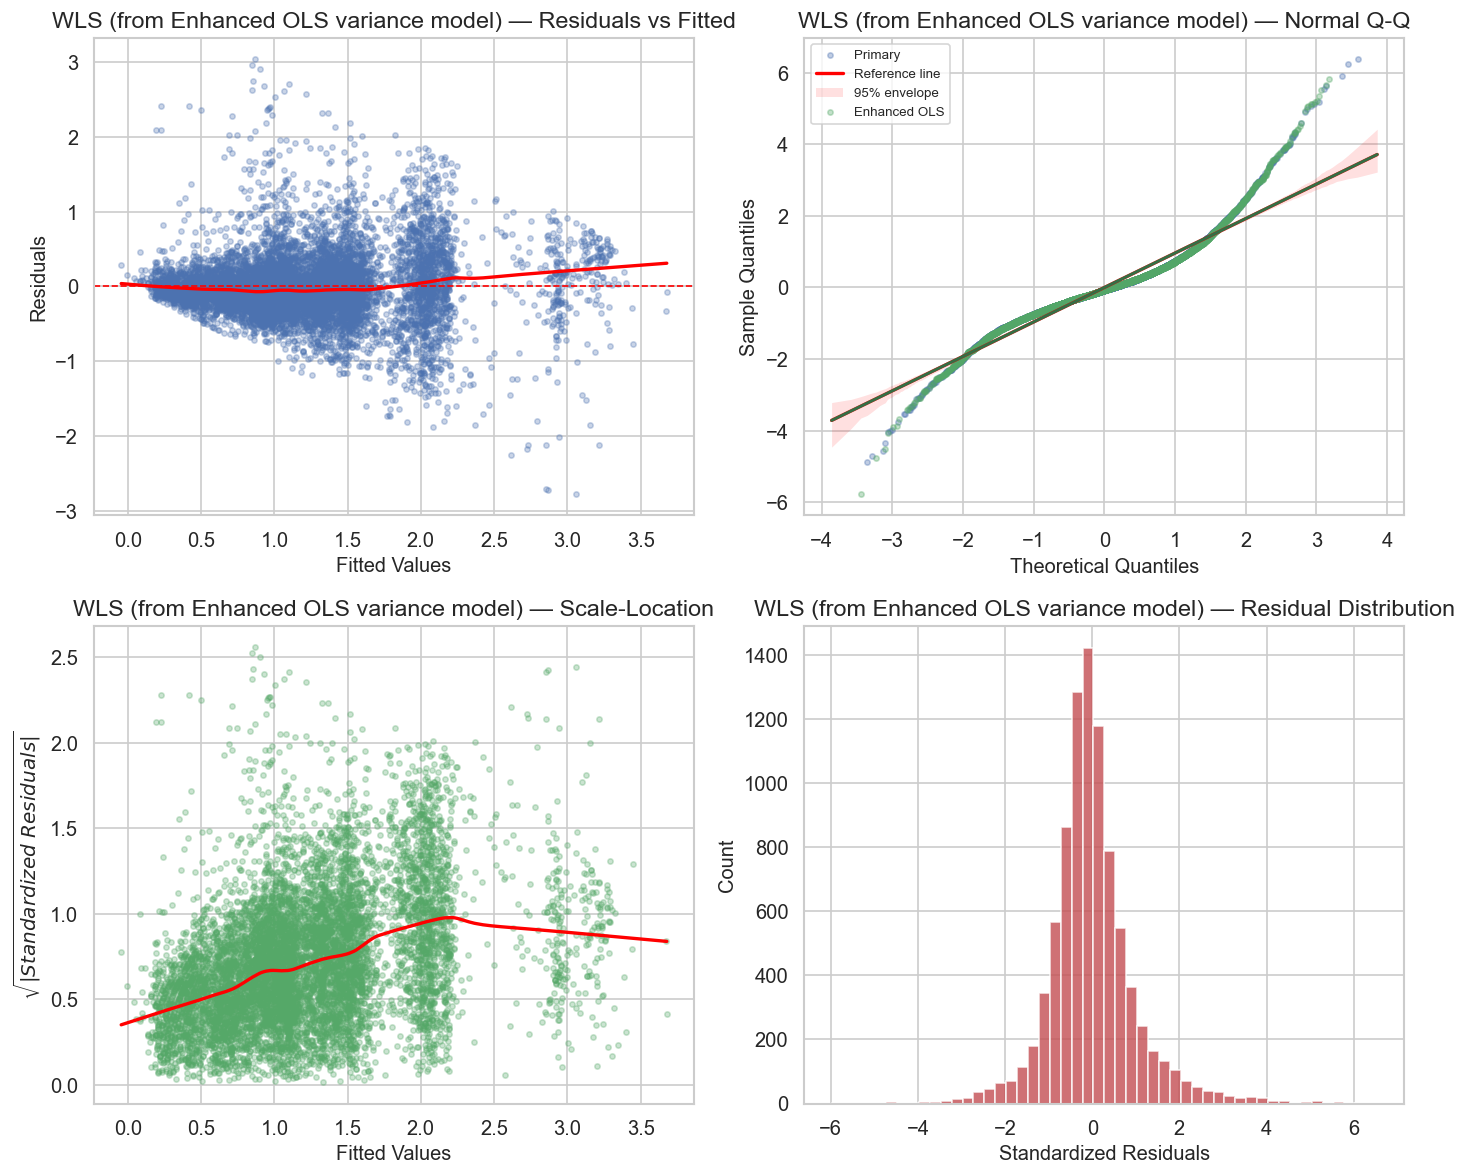

=== Enhanced OLS vs WLS vs Quantile (Median) ===
MAE: enhanced OLS=0.3157, WLS=0.3162, quantile=0.3091
WLS residual skewness: 0.760
WLS residual kurtosis: 7.825 (normal=3)
WLS Breusch-Pagan p-value: 6.61e-132

Selected coefficient comparison (Enhanced OLS / WLS / Q50):
                                          variable   enh_ols       wls       q50  abs_diff_wls_vs_enh  abs_diff_q50_vs_enh
                                         Intercept  2.468883  2.440285  2.459139             0.028598             0.009744
                              C(msi_status)[T.MSS] -2.129178 -2.058818 -2.143388             0.070360             0.014210
                     bs(age_at_diagnosis, df=4)[0] -0.042176 -0.033333 -0.018675             0.008843             0.023501
                     bs(age_at_diagnosis, df=4)[1]  0.363713  0.282377  0.293713             0.081335             0.069999
                     bs(age_at_diagnosis, df=4)[2]  0.274754  0.252505  0.306899             0.022249             0

In [14]:
# --- WLS: model variance as a function of fitted values ---
eps = 1e-6
aux_X = sm.add_constant(m_enh.fittedvalues.values)
aux_y = np.log(np.square(m_enh.resid.values) + eps)
var_model = sm.OLS(aux_y, aux_X).fit()
log_var_hat = var_model.predict(aux_X)
weights = 1.0 / np.exp(log_var_hat)

m_wls = sm.WLS(m_enh.model.endog, m_enh.model.exog, weights=weights).fit()
qq_resid_wls = (m_wls.resid - m_wls.resid.mean()) / m_wls.resid.std()

fig = plot_residual_diagnostics(
    m_wls.fittedvalues,
    m_wls.resid,
    model_name="WLS (from Enhanced OLS variance model)",
    qq_residuals=qq_resid_wls,
    qq_compare_residuals=qq_resid_enh,
    qq_compare_label="Enhanced OLS",
    qq_show_ci=True,
    qq_ci_level=0.95,
)
save_fig(fig, "diagnostics_residuals_4panel_wls", FIGURES_DIR)
plt.show()

# --- Quantile regression (median) on same design matrix ---
m_qr = sm.QuantReg(m_enh.model.endog, m_enh.model.exog).fit(q=0.5, max_iter=5000)
y_true = np.asarray(m_enh.model.endog)

mae_enh = np.mean(np.abs(y_true - m_enh.fittedvalues))
mae_wls = np.mean(np.abs(y_true - m_wls.fittedvalues))
mae_qr = np.mean(np.abs(y_true - m_qr.predict(m_enh.model.exog)))

wls_skew = sp_stats.skew(m_wls.resid)
wls_kurt = sp_stats.kurtosis(m_wls.resid, fisher=False)
bp_stat_wls, bp_pval_wls, _, _ = het_breuschpagan(m_wls.resid, m_wls.model.exog)

print("=== Enhanced OLS vs WLS vs Quantile (Median) ===")
print(f"MAE: enhanced OLS={mae_enh:.4f}, WLS={mae_wls:.4f}, quantile={mae_qr:.4f}")
print(f"WLS residual skewness: {wls_skew:.3f}")
print(f"WLS residual kurtosis: {wls_kurt:.3f} (normal=3)")
print(f"WLS Breusch-Pagan p-value: {bp_pval_wls:.2e}")

# Compare selected coefficients across methods
coef_comp = pd.DataFrame({
    "variable": m_enh.model.exog_names,
    "enh_ols": m_enh.params,
    "wls": m_wls.params,
    "q50": m_qr.params,
})
coef_comp["abs_diff_wls_vs_enh"] = (coef_comp["wls"] - coef_comp["enh_ols"]).abs()
coef_comp["abs_diff_q50_vs_enh"] = (coef_comp["q50"] - coef_comp["enh_ols"]).abs()

sel_coef = coef_comp[
    coef_comp["variable"].str.contains(
        "Intercept|msi_status|bs\\(age_at_diagnosis|bs\\(aneuploidy_score|bs\\(fraction_genome_altered",
        regex=True,
    )
]

print("\nSelected coefficient comparison (Enhanced OLS / WLS / Q50):")
print(sel_coef.head(20).to_string(index=False))

## 7. Sensitivity Analysis: Exclude SKCM + UCEC

In [15]:
if "cancer_type" in model_df.columns:
    # Identify SKCM and UCEC (may appear as full names or abbreviations)
    exclude_types = []
    for ct in model_df["cancer_type"].unique():
        ct_lower = str(ct).lower()
        if any(term in ct_lower for term in ["skcm", "melanoma", "ucec", "endometrial", "uterine corpus"]):
            exclude_types.append(ct)
    
    if exclude_types:
        print(f"Excluding: {exclude_types}")
        sens_df = model_df[~model_df["cancer_type"].isin(exclude_types)].copy()
        print(f"Samples remaining: {len(sens_df)} (removed {len(model_df) - len(sens_df)})")
        
        m_sens = fit_ols_formula(sens_df, full_formula)
        
        print(f"\nFull dataset adj R²:      {m_full.rsquared_adj:.4f}")
        print(f"Without SKCM/UCEC adj R²: {m_sens.rsquared_adj:.4f}")
        
        # Compare key coefficients
        sens_coef = extract_model_summary(m_sens)
        sens_non_ct = sens_coef[~sens_coef["variable"].str.startswith("C(cancer_type")]
        
        sens_comparison = ols_non_ct[["variable", "coef"]].merge(
            sens_non_ct[["variable", "coef"]],
            on="variable",
            suffixes=("_full", "_sensitivity"),
        )
        print("\nCoefficient stability (full vs sensitivity):")
        print(sens_comparison.to_string(index=False))
    else:
        print("Could not identify SKCM/UCEC cancer types in the data.")
        print(f"Available types: {sorted(model_df['cancer_type'].unique())}")

Excluding: ['Endometrial Cancer', 'Melanoma', 'Ocular Melanoma']
Samples remaining: 8447 (removed 943)

Full dataset adj R²:      0.6237
Without SKCM/UCEC adj R²: 0.6112

Coefficient stability (full vs sensitivity):
               variable  coef_full  coef_sensitivity
              Intercept   2.054780          1.930341
         C(sex)[T.MALE]   0.036846          0.034216
   C(msi_status)[T.MSS]  -1.743721         -1.670064
     C(wgd_status)[T.1]   0.130183          0.137379
       age_at_diagnosis   0.005395          0.005625
       aneuploidy_score  -0.001754         -0.001477
fraction_genome_altered   0.241555          0.302935


## 8. Logistic Model Diagnostics

  Saved: diagnostics_logistic_residuals.png, diagnostics_logistic_residuals.pdf


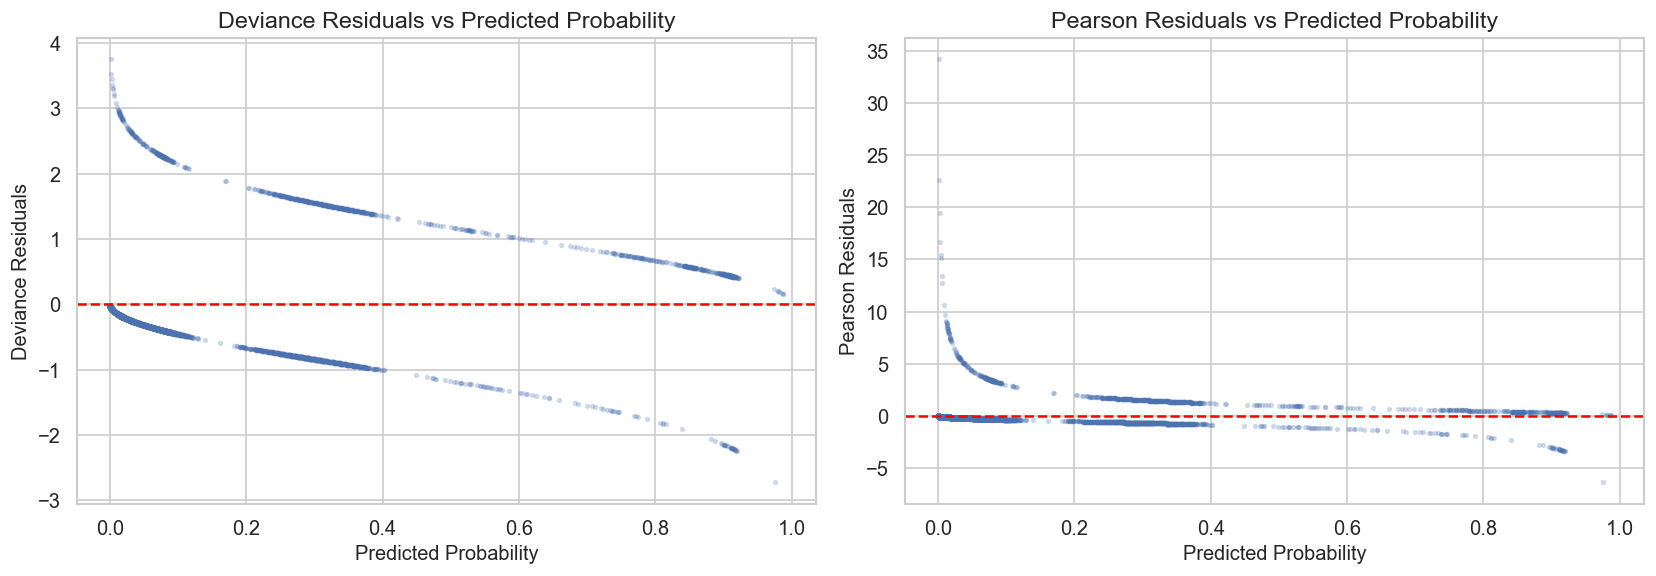

In [16]:
# Refit logistic model on full data (including hypermutators — classification task)
logit_df = get_model_df(df, available, "tmb_high")
logit_formula = "tmb_high ~ age_at_diagnosis + C(cancer_type) + C(sex) + C(msi_status) + aneuploidy_score + fraction_genome_altered + C(wgd_status)"

logit_result = sm.Logit.from_formula(logit_formula, data=logit_df).fit(method="bfgs", disp=0, maxiter=200)

# Use the model's actual endog/predict for consistent lengths
y_true = logit_result.model.endog.astype(int)
y_prob = logit_result.predict()

deviance_resid = np.sign(y_true - y_prob) * np.sqrt(
    -2 * (y_true * np.log(np.clip(y_prob, 1e-10, 1)) +
           (1 - y_true) * np.log(np.clip(1 - y_prob, 1e-10, 1)))
)

# Pearson residuals
pearson_resid = (y_true - y_prob) / np.sqrt(np.clip(y_prob * (1 - y_prob), 1e-10, None))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_prob, deviance_resid, alpha=0.2, s=5)
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Deviance Residuals")
axes[0].set_title("Deviance Residuals vs Predicted Probability")

axes[1].scatter(y_prob, pearson_resid, alpha=0.2, s=5)
axes[1].axhline(0, color="red", ls="--")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Pearson Residuals")
axes[1].set_title("Pearson Residuals vs Predicted Probability")

fig.tight_layout()
save_fig(fig, "diagnostics_logistic_residuals", FIGURES_DIR)
plt.show()

In [ ]:
# Standard vs Firth comparison
cat_cols = [c for c in ["cancer_type", "sex", "msi_status"] if c in logit_df.columns]
X_firth = pd.get_dummies(logit_df[available], columns=cat_cols, drop_first=True)
X_firth = X_firth.apply(pd.to_numeric, errors="coerce").dropna(axis=1)
y_firth = logit_df.loc[X_firth.index, "tmb_high"].astype(int)

firth_result = fit_firth_logistic(X_firth, y_firth)

std_coefs = extract_model_summary(logit_result)
std_non_ct = std_coefs[~std_coefs["variable"].str.contains("cancer_type", case=False)]

firth_df = pd.DataFrame({
    "variable": firth_result["feature_names"],
    "coef_firth": firth_result["coef"].flatten(),
})
firth_non_ct = firth_df[~firth_df["variable"].str.contains("cancer_type", case=False)]

print("Standard vs Firth coefficient comparison (non-cancer-type):")
print("\nStandard logistic:")
print(std_non_ct[["variable", "coef"]].to_string(index=False))
print("\nFirth logistic:")
print(firth_non_ct.to_string(index=False))
print("\nFirth coefficients should be shrunk toward zero relative to standard logistic,")
print("especially for variables involved in quasi-complete separation.")

## 9. Diagnostic Summary

In [ ]:
summary_data = {
    "Diagnostic Test": [
        "Breusch-Pagan (heteroscedasticity)",
        "Shapiro-Wilk (normality)",
        "VIF (multicollinearity)",
        "Cook's distance (influence)",
        "Robust vs OLS comparison",
        "Enhanced model residuals",
        "WLS refinement",
        "Quantile regression (q=0.5)",
        "Sensitivity (excl. SKCM/UCEC)",
    ],
    "Result": [
        f"LM = {bp_stat:.1f}, p = {bp_pval:.2e}",
        f"W = {sw_stat:.4f}, p = {sw_pval:.2e}",
        f"Max VIF = {vif_df['VIF'].max():.2f}",
        f"{len(influential)} influential obs ({len(influential)/n:.1%})",
        "See coefficient comparison above",
        (
            f"Adj R² {m_full.rsquared_adj:.3f} -> {m_enh.rsquared_adj:.3f}; "
            f"kurtosis {base_kurt:.2f} -> {enh_kurt:.2f}; "
            f"BP p {bp_pval:.2e} -> {bp_pval_enh:.2e}"
        ),
        (
            f"MAE {mae_enh:.3f} -> {mae_wls:.3f}; "
            f"WLS kurtosis {wls_kurt:.2f}; "
            f"WLS BP p {bp_pval_wls:.2e}"
        ),
        f"Median model MAE = {mae_qr:.3f}",
        "See coefficient comparison above",
    ],
    "Implication": [
        "Heteroscedasticity detected" if bp_pval < 0.05 else "Homoscedastic",
        "Non-normal (expected with large n)" if sw_pval < 0.05 else "Normal",
        "Collinearity concern" if vif_df['VIF'].max() > 5 else "No concern",
        "Review high-TMB cancer types",
        "Outlier sensitivity check",
        "Better fit, but tails still heavy",
        "Variance-aware fit under heteroscedasticity",
        "Robust to tail outliers (median-focused)",
        "Coefficient stability check",
    ],
}

summary_table = pd.DataFrame(summary_data)
summary_table.style.set_properties(**{"text-align": "left"})